In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder

In [7]:
# Load Dataset

df = pd.read_excel("BERT_Vectorized_Output.xlsx")

X = df.drop(columns=["Doc","Label"])
y = df["Label"]

In [8]:
#A4
def equal_width_binning(data, bins=10):

    binned_cols = []

    for col in data.columns:
        binned_col = pd.cut(data[col], bins=bins, labels=False)
        binned_cols.append(binned_col)

    binned = pd.concat(binned_cols, axis=1)
    binned.columns = data.columns

    return binned


X_binned = equal_width_binning(X, bins=10)
X_binned

,BERT_0,BERT_1,BERT_2,BERT_3,BERT_4,BERT_5,BERT_6,BERT_7,BERT_8,BERT_9,...,BERT_758,BERT_759,BERT_760,BERT_761,BERT_762,BERT_763,BERT_764,BERT_765,BERT_766,BERT_767
0,9,6,3,6,3,8,4,5,3,7,...,2,2,4,4,3,4,5,0,5,6
1,9,6,6,4,3,5,7,6,6,3,...,3,3,3,6,4,4,5,3,6,5
2,6,6,6,4,1,3,3,4,9,4,...,3,4,3,9,1,3,4,1,3,6
3,9,7,3,6,2,5,4,5,6,2,...,1,2,4,8,2,5,8,2,5,6
4,7,5,3,4,2,7,4,5,7,4,...,4,3,5,7,0,6,6,4,4,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
337,7,7,3,7,3,3,9,9,4,1,...,3,6,7,6,3,7,8,0,7,5
338,0,4,4,2,7,6,4,4,6,7,...,7,7,7,7,6,1,3,5,6,4
339,8,5,6,3,4,6,2,5,8,3,...,4,5,4,7,4,3,4,5,4,5
340,7,6,4,3,2,6,6,4,6,3,...,2,4,3,6,2,3,5,3,5,3


In [9]:
# A1
def entropy(column):

    probabilities = column.value_counts(normalize=True)

    H = -np.sum(probabilities * np.log2(probabilities))

    return H


dataset_entropy = entropy(y)

print("Dataset Entropy:", dataset_entropy)

Dataset Entropy: 0.964078764808229


In [10]:
# A2

def gini_index(column):

    probabilities = column.value_counts(normalize=True)

    gini = 1 - np.sum(probabilities**2)

    return gini


dataset_gini = gini_index(y)

print("Dataset Gini Index:", dataset_gini)

Dataset Gini Index: 0.47530864197530853


In [12]:
# A3

def information_gain(feature, target):
    total_entropy = entropy(target)
    values = feature.unique()
    weighted_entropy = 0
    
    for v in values:
        subset = target[feature == v]
        weight = len(subset) / len(target)
        weighted_entropy += weight * entropy(subset)
    IG = total_entropy - weighted_entropy

    return IG


info_gain_values = {}

for col in X_binned.columns:

    info_gain_values[col] = information_gain(X_binned[col], y)


# Root feature
root_feature = max(info_gain_values, key=info_gain_values.get)

print("Root Feature based on Information Gain:", root_feature)

Root Feature based on Information Gain: BERT_286


In [13]:
# A5

def build_decision_tree(X, y):

    clf = DecisionTreeClassifier(
        criterion="entropy",
        max_depth=5
    )

    clf.fit(X, y)

    return clf


tree_model = build_decision_tree(X_binned, y)

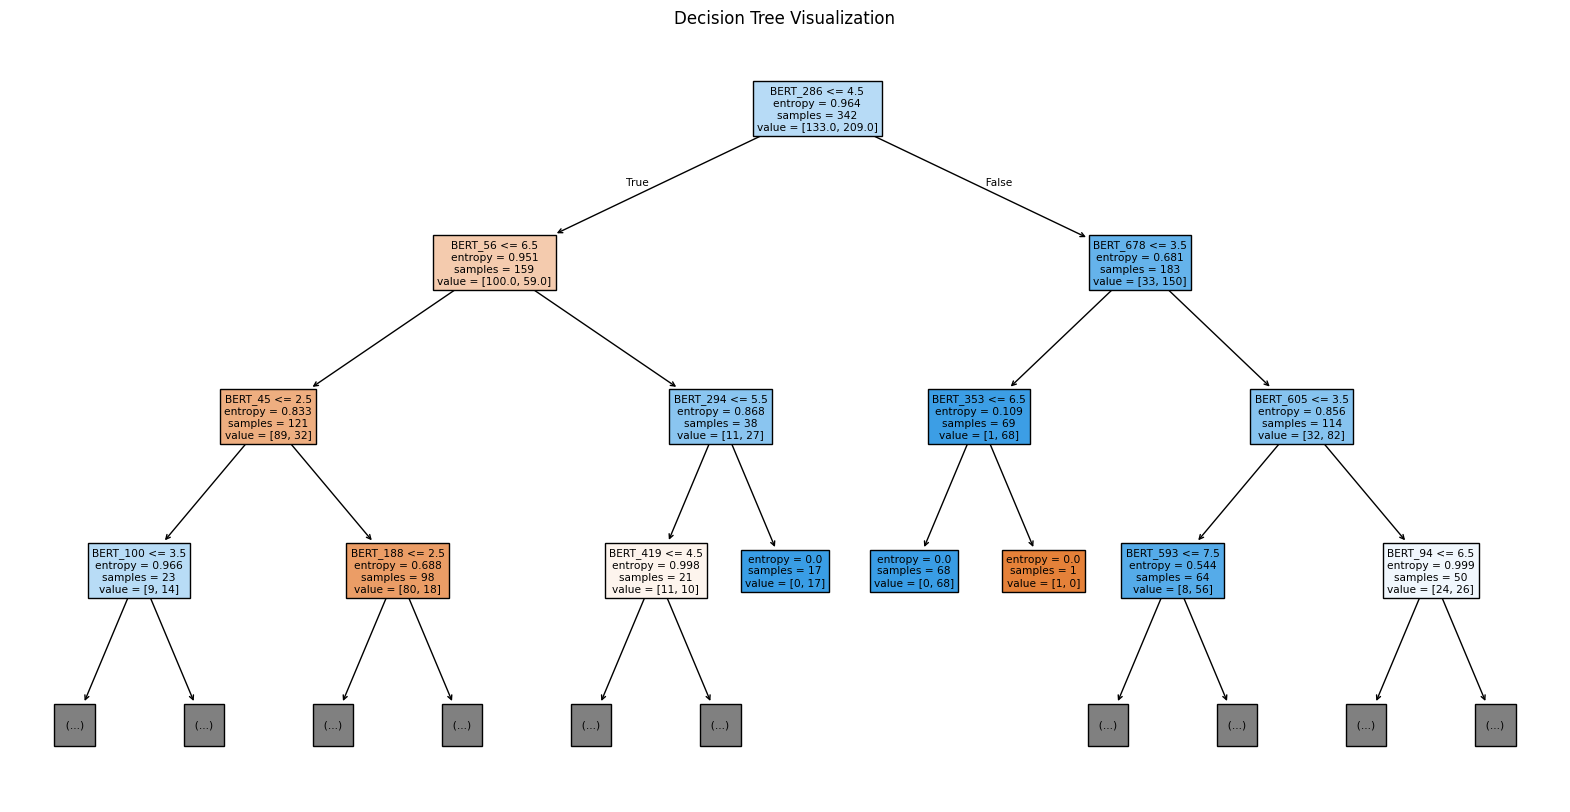

In [14]:
# A6
plt.figure(figsize=(20,10))

plot_tree(
    tree_model,
    filled=True,
    max_depth=3,
    feature_names=X_binned.columns
)

plt.title("Decision Tree Visualization")

plt.show()

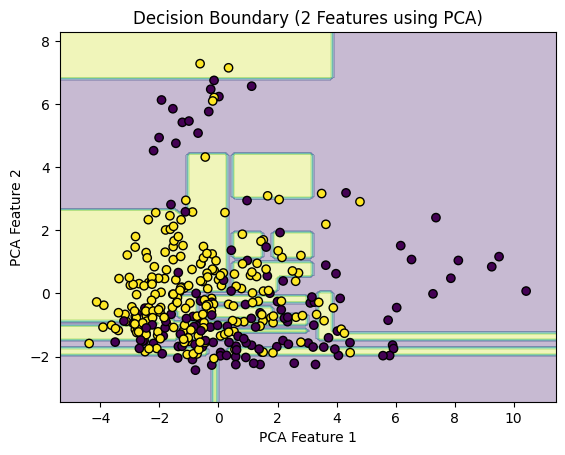

In [17]:
#A7

le = LabelEncoder()
y_encoded = le.fit_transform(y)


pca = PCA(n_components=2)
X_2D = pca.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_2D, y_encoded, test_size=0.2, random_state=42
)

model_2D = DecisionTreeClassifier()
model_2D.fit(X_train, y_train)

x_min, x_max = X_2D[:,0].min()-1, X_2D[:,0].max()+1
y_min, y_max = X_2D[:,1].min()-1, X_2D[:,1].max()+1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 100),
    np.linspace(y_min, y_max, 100)
)

Z = model_2D.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)

plt.scatter(
    X_2D[:,0],
    X_2D[:,1],
    c=y_encoded,
    edgecolor='k'
)

plt.title("Decision Boundary (2 Features using PCA)")
plt.xlabel("PCA Feature 1")
plt.ylabel("PCA Feature 2")

plt.show()